# 0.0 Imports

In [2]:
!pip install inflection

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import inflection

from matplotlib import pyplot as plt
from IPython.display    import HTML
from ydata_profiling import ProfileReport

d:\Comunidade DS\Portifólio de Projetos\repos\ds_fraud\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.1 Helper Functions

In [4]:
def jupyter_settings():
    %matplotlib inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )

    sns.set()

jupyter_settings()

In [5]:
jupyter_settings()

## 0.2 Loading Data

In [6]:
df_raw = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv', low_memory=False)

In [7]:
df_raw.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2188569,185,PAYMENT,4291.75,C1196095168,0.0,0.0,M1282388742,0.0,0.0,0,0


# 1.0 Descrição dos dados

In [8]:
df1 = df_raw.copy()

## 1.1 Rename Columns

In [9]:
df1.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [10]:
cols_old = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud']

snakecase = lambda x: inflection.underscore( x )

cols_new = list (map (snakecase, cols_old))


df1.columns = cols_new

## 1.2 Data Dimensions

In [11]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Columns: {}'.format(df1.shape[1]))

Number of Rows: 6362620
Number of Columns: 11


## 1.3 Data Types

In [12]:
df1.dtypes

step                  int64
type                 object
amount              float64
name_orig            object
oldbalance_org      float64
newbalance_orig     float64
name_dest            object
oldbalance_dest     float64
newbalance_dest     float64
is_fraud              int64
is_flagged_fraud      int64
dtype: object

## 1.4 Check NA

In [13]:
df1.isna().sum()

step                0
type                0
amount              0
name_orig           0
oldbalance_org      0
newbalance_orig     0
name_dest           0
oldbalance_dest     0
newbalance_dest     0
is_fraud            0
is_flagged_fraud    0
dtype: int64

## 1.5 Descriptive Statistical

In [14]:
# profile = ProfileReport(df1)
# profile.to_file('../reports/raw_data_report.html')

In [15]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

In [16]:
cat_attributes.sample(5)

,type,name_orig,name_dest
5436164,PAYMENT,C897400830,M1066329282
720201,TRANSFER,C1282438932,C1495731688
4853704,PAYMENT,C636816113,M1505720484
2287861,CASH_IN,C491737115,C236523671
2831253,PAYMENT,C2139309618,M1027271864


### 1.5.1 Numerical Attributes

In [17]:
# Central Tendency - mean, median

ct1 = pd.DataFrame (num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame (num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis

d1 = pd.DataFrame (num_attributes.apply(np.std)).T
d2 = pd.DataFrame (num_attributes.apply(min)).T
d3 = pd.DataFrame (num_attributes.apply(max)).T
d4= pd.DataFrame (num_attributes.apply(lambda x: x.max() - x.min())).T
d5= pd.DataFrame (num_attributes.apply(lambda x: x.skew())).T
d6= pd.DataFrame (num_attributes.apply(lambda x: x.kurtosis())).T

# concatenate
m = pd.concat([d2 ,d3 ,d4 , ct1 ,ct2 , d1 , d5 , d6]).T.reset_index()
m. columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis' ]

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,step,1.0,7.430000e+02,7.420000e+02,2.433972e+02,239.000,1.423320e+02,0.375177,0.329071
1,amount,0.0,9.244552e+07,9.244552e+07,1.798619e+05,74871.940,6.038582e+05,30.993949,1797.956705
2,oldbalance_org,0.0,5.958504e+07,5.958504e+07,8.338831e+05,14208.000,2.888242e+06,5.249136,32.964879
3,newbalance_orig,0.0,4.958504e+07,4.958504e+07,8.551137e+05,0.000,2.924048e+06,5.176884,32.066985
4,oldbalance_dest,0.0,3.560159e+08,3.560159e+08,1.100702e+06,132705.665,3.399180e+06,19.921758,948.674125
5,newbalance_dest,0.0,3.561793e+08,3.561793e+08,1.224996e+06,214661.440,3.674129e+06,19.352302,862.156508
6,is_fraud,0.0,1.000000e+00,1.000000e+00,1.290820e-03,0.000,3.590479e-02,27.779538,769.702982
7,is_flagged_fraud,0.0,1.000000e+00,1.000000e+00,2.514687e-06,0.000,1.585775e-03,630.603629,397659.062500


### 1.5.2 Categorical Attributes

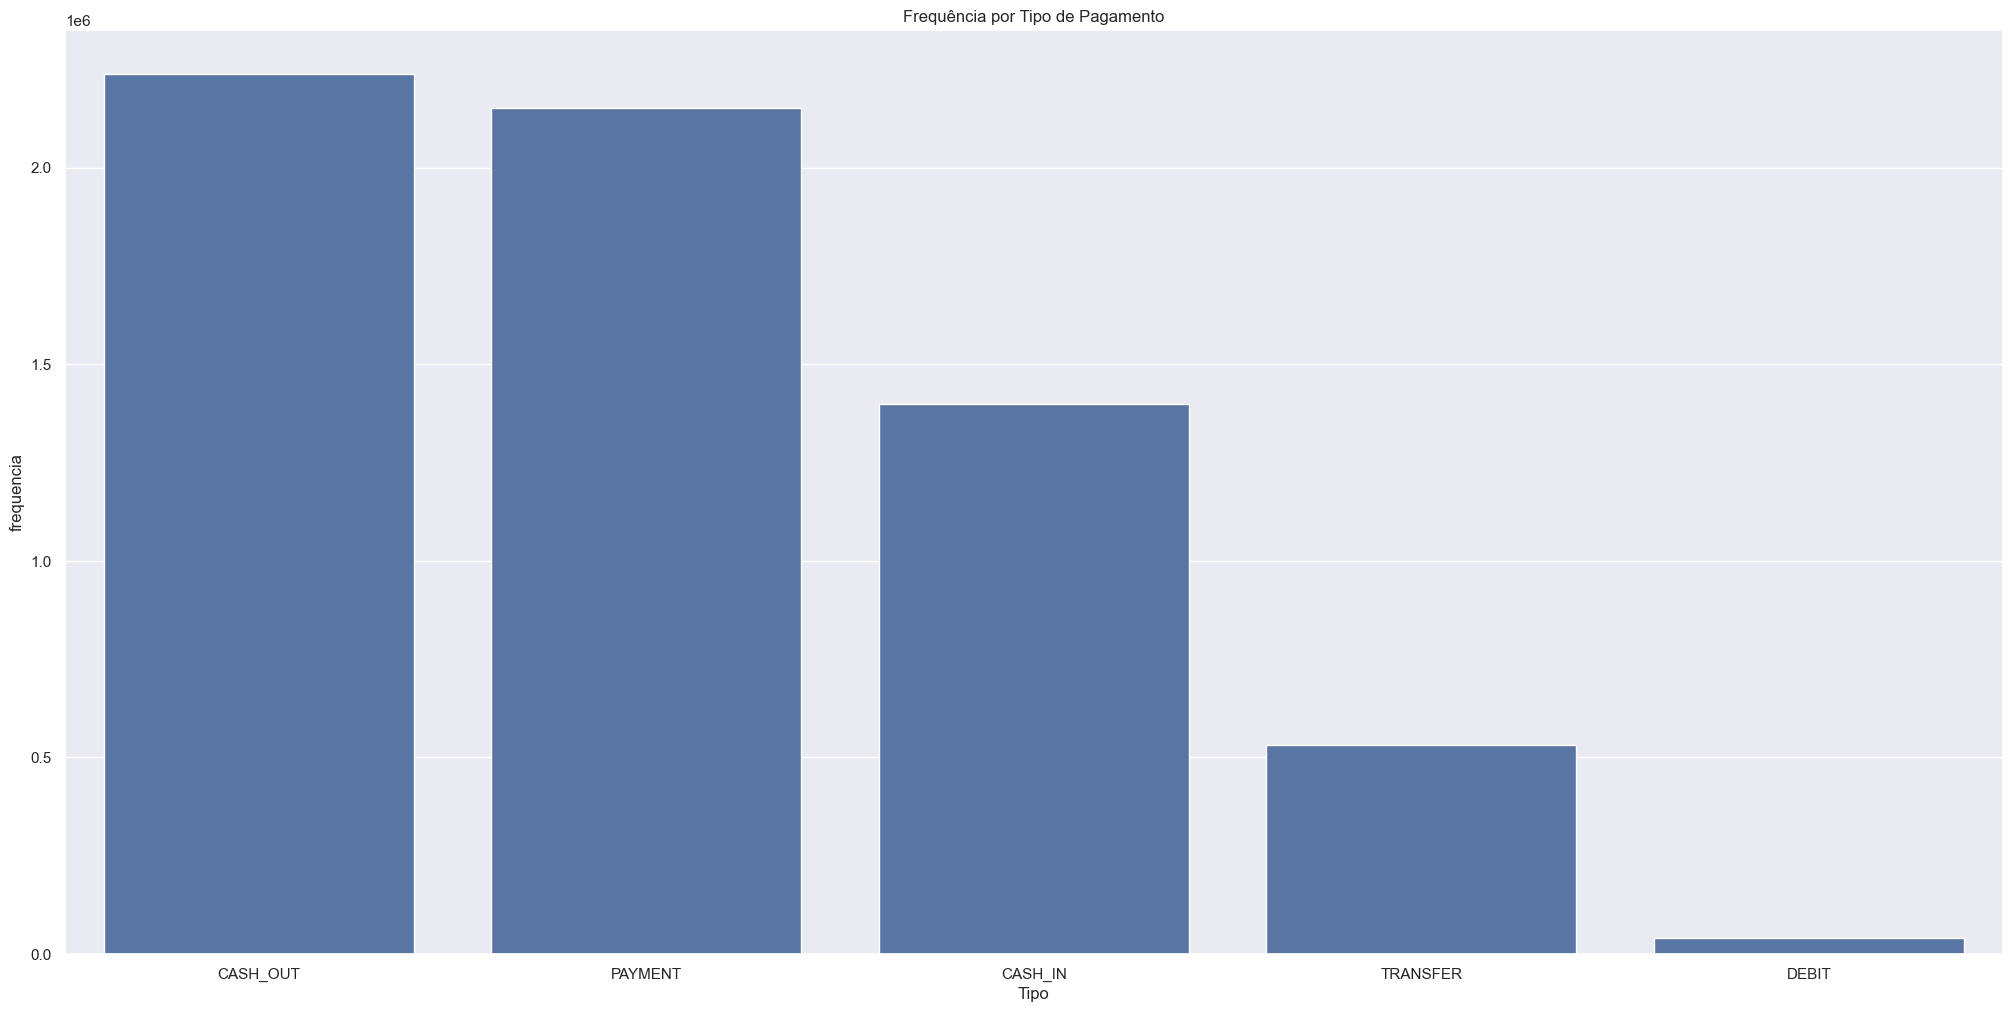

In [18]:
contagem = df1['type'].value_counts().reset_index()
contagem.columns = ['Tipo', 'frequencia']

# Gráfico de barras
sns.barplot(data=contagem, x='Tipo', y='frequencia')
plt.title('Frequência por Tipo de Pagamento')
plt.show()

## Check Frauds

In [19]:
df_fraud = df1[df1['is_fraud'] == 1]
df_flagged_fraud = df1[df1['is_flagged_fraud'] == 1] 

In [20]:
df_fraud.shape

(8213, 11)

In [21]:
df_flagged_fraud.shape

(16, 11)

In [22]:
df_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud
6118752,534,CASH_OUT,492896.75,C1604057641,492896.75,0.0,C773898763,10420895.10,10913791.86,1,0
4785643,340,CASH_OUT,4677358.76,C171367749,4677358.76,0.0,C725544013,0.00,4677358.76,1,0
338008,16,CASH_OUT,2701905.30,C2140905252,2701905.30,0.0,C970796050,57418.00,2759323.30,1,0
3193197,244,TRANSFER,53338.82,C1248176014,53338.82,0.0,C26405591,0.00,0.00,1,0
6262607,612,TRANSFER,125216.91,C1019916893,125216.91,0.0,C1183977547,0.00,0.00,1,0
5188011,363,CASH_OUT,1715635.41,C356781229,1715635.41,0.0,C159373411,0.00,1715635.41,1,0
1030325,56,TRANSFER,530733.43,C176579882,530733.43,0.0,C1049193275,0.00,0.00,1,0
1030500,68,CASH_OUT,281743.12,C47524114,281743.12,0.0,C645628840,158099.98,439843.09,1,0
4556351,327,CASH_OUT,185238.61,C935134354,185238.61,0.0,C939313752,37287.36,222525.97,1,0
1030344,58,CASH_OUT,3156421.43,C597790533,3156421.43,0.0,C1365109989,181440.45,3337861.88,1,0


In [23]:
# Para ter uma flag de fraud é quando a transação é maior que 200k
df_flagged_fraud.sample(16)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud
5996409,425,TRANSFER,9585040.37,C452586515,19585040.37,19585040.37,C1109166882,0.0,0.0,1,1
5996407,425,TRANSFER,10000000.00,C689608084,19585040.37,19585040.37,C1392803603,0.0,0.0,1,1
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1
6281482,646,TRANSFER,10000000.00,C19004745,10399045.08,10399045.08,C1806199534,0.0,0.0,1,1
6296014,671,TRANSFER,3441041.46,C917414431,3441041.46,3441041.46,C1082139865,0.0,0.0,1,1
6362462,730,TRANSFER,7316255.05,C1869569059,17316255.05,17316255.05,C1861208726,0.0,0.0,1,1
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1
6362584,741,TRANSFER,5674547.89,C992223106,5674547.89,5674547.89,C1366804249,0.0,0.0,1,1
6281484,646,TRANSFER,399045.08,C724693370,10399045.08,10399045.08,C1909486199,0.0,0.0,1,1


# 2.0 Feature Engineering

In [24]:
df2 = df1.copy()

In [25]:
def period(h):
    if 5 <= h < 12:
        return 'Morning'
    elif 12 <= h < 18:
        return 'Afternoon'
    elif 18 <= h < 24:
        return 'Evening'
    else:
        return 'Night'

In [26]:
# dia

df2['day'] = (df2['step'] // 24) + 1

# hora 

df2['hora'] = df2['step'] % 24

# periodo do dia

df2['period_of_day'] = df2['hora'].apply(period)



In [27]:
df2.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
6176159,565,PAYMENT,2712.75,C1928733780,30729.0,28016.25,M1969936955,0.00,0.00,0,0,24,13,Afternoon
6054408,495,CASH_IN,233207.97,C518422536,4772593.5,5005801.48,C440034553,662903.97,429696.00,0,0,21,15,Afternoon
5037054,354,CASH_OUT,61670.51,C1707996845,40032.0,0.00,C660041119,252208.88,313879.38,0,0,15,18,Evening
1303046,136,CASH_OUT,301670.00,C2052982905,0.0,0.00,C1150970228,400710.70,702380.70,0,0,6,16,Afternoon
1108661,130,CASH_IN,182913.75,C479560778,4724.0,187637.75,C677701060,3066123.63,2703126.06,0,0,6,10,Morning


In [28]:
df_aux_fraud1 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Morning')]
df_aux_fraud2 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Afternoon')]
df_aux_fraud3 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Evening')]
df_aux_fraud4 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Night')]

In [31]:
print(f"Fraudes no periodo da manha: {df_aux_fraud1.shape[0]}")
print(f"Fraudes no periodo da tarde: {df_aux_fraud2.shape[0]}")
print(f"Fraudes no periodo da noite: {df_aux_fraud3.shape[0]}")
print(f"Fraudes no periodo da madrugada: {df_aux_fraud4.shape[0]}")

Fraudes no periodo da manha: 2460
Fraudes no periodo da tarde: 2077
Fraudes no periodo da noite: 2046
Fraudes no periodo da madrugada: 1630


In [32]:
df_aux2 = df2[df2['name_orig'].str.contains(r'^M', na=False)]

In [ ]:
df_aux2.sample(5)


KeyboardInterrupt



# 3.0 Filtragem de Variáveis

# 4.0 Análise Exploratória de Dados

# 5.0 Data Preparation

# 6.0 Feature Selection

# 7.0 Machine Learning Modeling

# 8.0 Hyperparameter Fine Tunnig

# 9.0 Final Model